#### Cargar librerias

In [42]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

#### Cargar datos

In [39]:
# Cargar el archivo .npy
datos_000 = np.load('../Rehab_exercise/d02_processed_data/000_1.npy')

#### Dimensiones

In [40]:
# shape
datos_000.shape

(232, 880, 6)

- 232 = hay 232 muestras del movimiento 000.

- 880 = cada muestra tiene 880 mediciones/puntos en el tiempo.

- 6 = en cada punto temporal hay 6 variables o canales.

En cada una de las 232 muestras, hay 880 puntos de tiempo, y en cada punto se guardaron 6 mediciones.

#### Verifica si las lecturas del sensor 1 corresponden a las mismas lecturas del sensor 2. Tendrás que idear una forma de como corroborar esto.

In [35]:
ruta = "../Rehab_exercise/d02_processed_data/"

for i in range(16):

    # Omitimos temporalmente 014 por el problema del archivo
    if i == 14:
        continue

    nombre_archivo = f"{i:03d}_1.npy"
    datos = np.load(os.path.join(ruta, nombre_archivo))

    # Sensor 1: pitch1, yaw1, roll1
    sensor1 = datos[:, :, 0:3]

    # Sensor 2: pitch2, yaw2, roll2
    sensor2 = datos[:, :, 3:6]

    print(
        f"Actividad {i:03d}: "
        f"S1 = {sensor1.shape[0]} muestras | "
        f"S2 = {sensor2.shape[0]} muestras"
    )

Actividad 000: S1 = 232 muestras | S2 = 232 muestras
Actividad 001: S1 = 212 muestras | S2 = 212 muestras
Actividad 002: S1 = 267 muestras | S2 = 267 muestras
Actividad 003: S1 = 250 muestras | S2 = 250 muestras
Actividad 004: S1 = 287 muestras | S2 = 287 muestras
Actividad 005: S1 = 293 muestras | S2 = 293 muestras
Actividad 006: S1 = 260 muestras | S2 = 260 muestras
Actividad 007: S1 = 385 muestras | S2 = 385 muestras
Actividad 008: S1 = 299 muestras | S2 = 299 muestras
Actividad 009: S1 = 307 muestras | S2 = 307 muestras
Actividad 010: S1 = 311 muestras | S2 = 311 muestras
Actividad 011: S1 = 235 muestras | S2 = 235 muestras
Actividad 012: S1 = 293 muestras | S2 = 293 muestras
Actividad 013: S1 = 313 muestras | S2 = 313 muestras
Actividad 015: S1 = 313 muestras | S2 = 313 muestras


#### Selecciona una de las actividades y toma una de las repeticiones. Selecciona uno de los canales del sensor y grafica sus valores en el tiempo.

Seleccionamos el sensor 1 

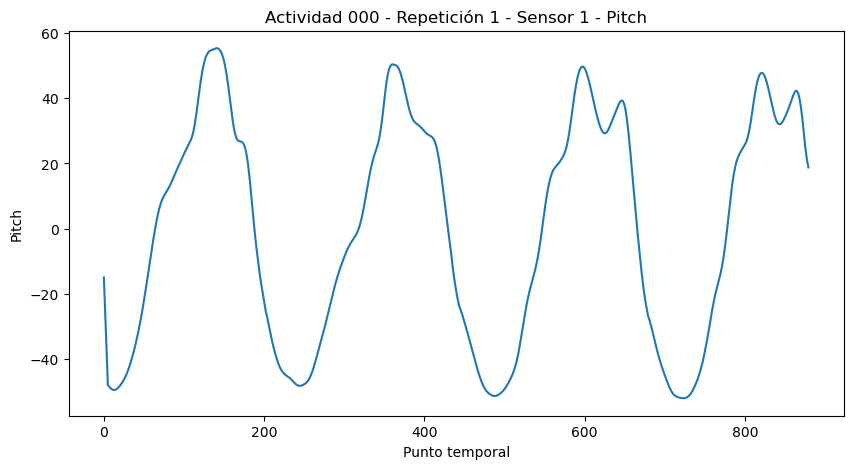

In [41]:
repeticion = datos_000[0]

pitch1 = repeticion[:, 0]

plt.figure(figsize=(10, 5))
plt.plot(pitch1)

plt.xlabel("Punto temporal")
plt.ylabel("Pitch")
plt.title("Actividad 000 - Repetición 1 - Sensor 1 - Pitch")

plt.show()

#### Genera una gráfica de barras donde el eje X muestre cada actividad y el eje Y el conteo total de cuántas repeticiones existen para esa actividad (usado todos los datos). ¿Se ven balanceados los conteos?

In [ ]:

ruta = "../Rehab_exercise/d02_processed_data/"

actividades = []
repeticiones = []

for i in range(16):

    # Ignoramos temporalmente la actividad 014
    if i == 14:
        continue

    nombre_archivo = f"{i:03d}_1.npy"

    datos_actividad = np.load(os.path.join(ruta, nombre_archivo))

    actividades.append(f"{i:03d}")
    repeticiones.append(datos_actividad.shape[0])

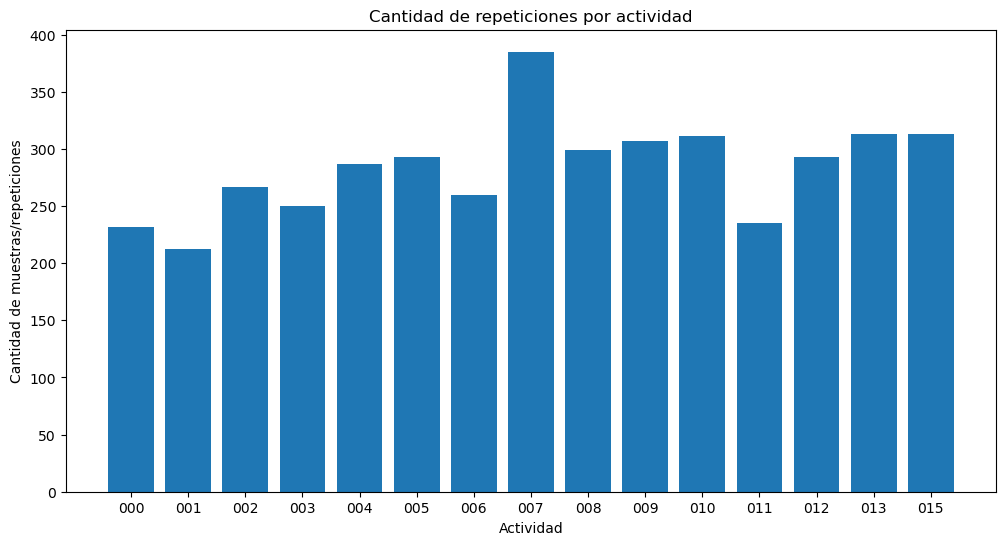

In [31]:
plt.figure(figsize=(12, 6))

plt.bar(actividades, repeticiones)

plt.xlabel("Actividad")
plt.ylabel("Cantidad de muestras/repeticiones")
plt.title("Cantidad de repeticiones por actividad")

plt.show()

#### Elige un canal del sensor y calcula la media y mediana de todos los valores de una actividad en específico. Haz esto para cada actividad y genera una tabla con 16 filas y dos columnas. Las filas son la actividad y las columnas sus valores de meda y mediana. Puedes concatenar todas las repeticiones de una actividad y calcular los estadísticos sobre los datos concatenados.


In [36]:
# Aquí guardaremos los resultados
resultados = []

# Aquí guardaremos los valores concatenados de cada actividad - para usarlos después
datos_pitch = {}

# Recorremos las 16 actividades
for i in range(16):

    # Omitimos temporalmente 014 porque el archivo tiene un problema
    if i == 14:
        continue

    nombre_archivo = f"{i:03d}_1.npy"

    datos_actividad = np.load(
        os.path.join(ruta, nombre_archivo)
    )

    # Seleccionamos pitch1:
    pitch1 = datos_actividad[:, :, 0]

    # Convertimos todas las muestras y todos sus puntos
    # en un solo arreglo de una dimensión
    pitch1_concatenado = pitch1.flatten()

    # Calculamos media y mediana
    media = np.mean(pitch1_concatenado)
    mediana = np.median(pitch1_concatenado)
    
    # Guardamos los valores concatenados para usarlos después
    datos_pitch[f"{i:03d}"] = pitch1_concatenado

    # Guardamos los resultados de esta actividad
    resultados.append({
        "Actividad": f"{i:03d}",
        "Media": media,
        "Mediana": mediana
    })

# Convertimos los resultados en una tabla
tabla = pd.DataFrame(resultados)

tabla

,Actividad,Media,Mediana
0,000,-1.147114e-16,1.587262
1,001,1.675808e-17,0.000000
2,002,-8.709410e-17,1.092490
3,003,-5.270935e-17,-3.553140
4,004,1.260386e-17,0.000000
5,005,-2.204600e-19,0.000000
6,006,2.921672e-16,0.000000
7,007,2.114011e-17,-0.050467
8,008,-8.641444e-17,-3.178819
9,009,0.000000e+00,-1.969354


#### Elige dos actividades diferentes y grafica su histograma (de la concatenación de todas las repeticiones) del canal seleccionado. Incluye los dos histogramas en la misma gráfica para ver que tanto se traslapan.

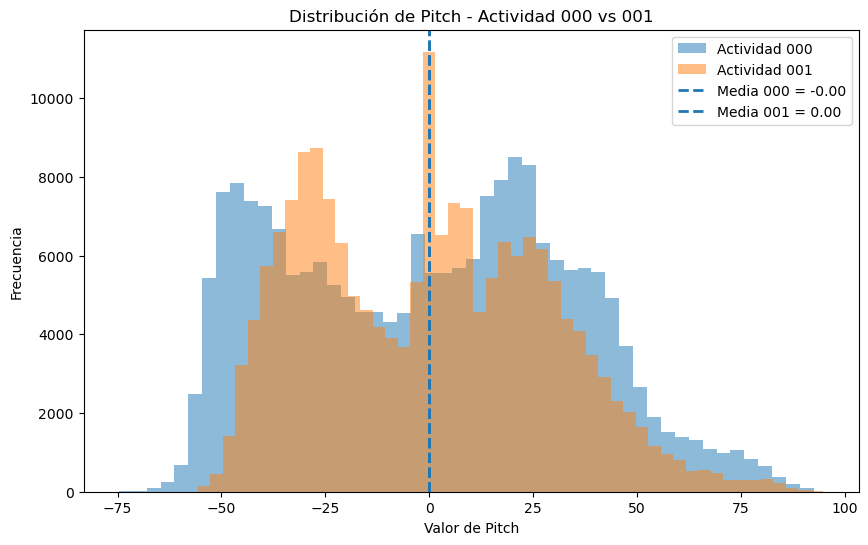

In [47]:
actividad_000 = datos_pitch["000"]
actividad_001 = datos_pitch["001"]

# Calculamos la media de cada actividad
media_000 = np.mean(actividad_000)
media_001 = np.mean(actividad_001)

plt.figure(figsize=(10, 6))

# Histogramas
plt.hist(
    actividad_000,
    bins=50,
    alpha=0.5,
    label="Actividad 000"
)

plt.hist(
    actividad_001,
    bins=50,
    alpha=0.5,
    label="Actividad 001"
)

# Línea vertical que representa la media de cada actividad
plt.axvline(
    media_000,
    linestyle="--",
    linewidth=2,
    label=f"Media 000 = {media_000:.2f}"
)

plt.axvline(
    media_001,
    linestyle="--",
    linewidth=2,
    label=f"Media 001 = {media_001:.2f}"
)

plt.xlabel("Valor de Pitch")
plt.ylabel("Frecuencia")
plt.title("Distribución de Pitch - Actividad 000 vs 001")

plt.legend()
plt.show()

Los histogramas de las actividades 000 y 001 presentan un traslape considerable, por lo que el canal pitch1 por sí solo no parece separar claramente ambas actividades. Sin embargo, existen algunas diferencias en la forma y concentración de los valores, por lo que este canal sí podría aportar información cuando se combine con otros canales.


Para probar diferentes actividades cambiar en # el numero de actividad
 - actividad_00# = datos_pitch["00#"] 
-  actividad_00# = datos_pitch["00#"]